# **Linear Regression with Uber and Lyft Ride Data**

In [2]:
'''from google.colab import files
uploaded = files.upload()'''

from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


import libraries:

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
pd.options.display.max_rows = None
pd.options.display.max_columns = None
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, Ridge
from sklearn.linear_model import LassoCV, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

In [4]:
df=pd.read_csv("/content/drive/MyDrive/rideshare_kaggle.csv")

## 1. Data Preprocessing and Exploratory Analysis

In [6]:
print(df.shape)
df.info()
df.head()


(693070, 57)
<class 'pandas.core.frame.DataFrame'>
Index: 693070 entries, 0 to 693070
Data columns (total 57 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   id                           693070 non-null  object        
 1   timestamp                    693070 non-null  float64       
 2   hour                         693070 non-null  int64         
 3   day                          693070 non-null  int32         
 4   month                        693070 non-null  int64         
 5   datetime                     693070 non-null  datetime64[ns]
 6   timezone                     693070 non-null  object        
 7   source                       693070 non-null  object        
 8   destination                  693070 non-null  object        
 9   cab_type                     693070 non-null  object        
 10  product_id                   693070 non-null  object        
 11  name              

,id,timestamp,hour,day,month,datetime,timezone,source,destination,cab_type,product_id,name,price,distance,surge_multiplier,latitude,longitude,temperature,apparentTemperature,short_summary,long_summary,precipIntensity,precipProbability,humidity,windSpeed,windGust,windGustTime,visibility,temperatureHigh,temperatureHighTime,temperatureLow,temperatureLowTime,apparentTemperatureHigh,apparentTemperatureHighTime,apparentTemperatureLow,apparentTemperatureLowTime,icon,dewPoint,pressure,windBearing,cloudCover,uvIndex,visibility.1,ozone,sunriseTime,sunsetTime,moonPhase,precipIntensityMax,uvIndexTime,temperatureMin,temperatureMinTime,temperatureMax,temperatureMaxTime,apparentTemperatureMin,apparentTemperatureMinTime,apparentTemperatureMax,apparentTemperatureMaxTime
0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,1.544953e+09,9,16,12,2018-12-16 09:30:07,America/New_York,Haymarket Square,North Station,Lyft,lyft_line,Shared,5.0,0.44,1.0,42.2148,-71.033,42.34,37.12,Mostly Cloudy,Rain throughout the day.,0.0000,0.0,0.68,8.66,9.17,1545015600,10.000,43.68,1544968800,34.19,1545048000,37.95,1544968800,27.39,1545044400,partly-cloudy-night,32.70,1021.98,57,0.72,0,10.000,303.8,1544962084,1544994864,0.30,0.1276,1544979600,39.89,1545012000,43.68,1544968800,33.73,1545012000,38.07,1544958000
1,4bd23055-6827-41c6-b23b-3c491f24e74d,1.543284e+09,2,27,11,2018-11-27 02:00:23,America/New_York,Haymarket Square,North Station,Lyft,lyft_premier,Lux,11.0,0.44,1.0,42.2148,-71.033,43.58,37.35,Rain,"Rain until morning, starting again in the eve...",0.1299,1.0,0.94,11.98,11.98,1543291200,4.786,47.30,1543251600,42.10,1543298400,43.92,1543251600,36.20,1543291200,rain,41.83,1003.97,90,1.00,0,4.786,291.1,1543232969,1543266992,0.64,0.1300,1543251600,40.49,1543233600,47.30,1543251600,36.20,1543291200,43.92,1543251600
2,981a3613-77af-4620-a42a-0c0866077d1e,1.543367e+09,1,28,11,2018-11-28 01:00:22,America/New_York,Haymarket Square,North Station,Lyft,lyft,Lyft,7.0,0.44,1.0,42.2148,-71.033,38.33,32.93,Clear,Light rain in the morning.,0.0000,0.0,0.75,7.33,7.33,1543334400,10.000,47.55,1543320000,33.10,1543402800,44.12,1543320000,29.11,1543392000,clear-night,31.10,992.28,240,0.03,0,10.000,315.7,1543319437,1543353364,0.68,0.1064,1543338000,35.36,1543377600,47.55,1543320000,31.04,1543377600,44.12,1543320000
3,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,1.543554e+09,4,30,11,2018-11-30 04:53:02,America/New_York,Haymarket Square,North Station,Lyft,lyft_luxsuv,Lux Black XL,26.0,0.44,1.0,42.2148,-71.033,34.38,29.63,Clear,Partly cloudy throughout the day.,0.0000,0.0,0.73,5.28,5.28,1543514400,10.000,45.03,1543510800,28.90,1543579200,38.53,1543510800,26.20,1543575600,clear-night,26.64,1013.73,310,0.00,0,10.000,291.1,1543492370,1543526114,0.75,0.0000,1543507200,34.67,1543550400,45.03,1543510800,30.30,1543550400,38.53,1543510800
4,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,1.543463e+09,3,29,11,2018-11-29 03:49:20,America/New_York,Haymarket Square,North Station,Lyft,lyft_plus,Lyft XL,9.0,0.44,1.0,42.2148,-71.033,37.44,30.88,Partly Cloudy,Mostly cloudy throughout the day.,0.0000,0.0,0.70,9.14,9.14,1543446000,10.000,42.18,1543420800,36.71,1543478400,35.75,1543420800,30.29,1543460400,partly-cloudy-night,28.61,998.36,303,0.44,0,10.000,347.7,1543405904,1543439738,0.72,0.0001,1543420800,33.10,1543402800,42.18,1543420800,29.11,1543392000,35.75,1543420800


In [7]:
df['datetime']=pd.to_datetime(df['datetime'])

### Data Cleaning

In [8]:
# Missing Values
print(df.isnull().sum())
print("----------------------------------")
df.dropna(axis=0,inplace=True)
print(df.isnull().sum())

id                                 0
timestamp                          0
hour                               0
day                                0
month                              0
datetime                           0
timezone                           0
source                             0
destination                        0
cab_type                           0
product_id                         0
name                               0
price                          55095
distance                           0
surge_multiplier                   0
latitude                           0
longitude                          0
temperature                        0
apparentTemperature                0
short_summary                      0
long_summary                       0
precipIntensity                    0
precipProbability                  0
humidity                           0
windSpeed                          0
windGust                           0
windGustTime                       0
v

In [9]:
# duplicate cols
df['visibility'].equals(df['visibility.1']) # these two cols are the same so i drop one


True

In [10]:
df = df.drop(['visibility.1'],axis=1)
print(df.shape)

(637975, 56)


### Time Analysis

In [11]:
def plot_bar(groupby_column):

    counts = df[groupby_column].value_counts().sort_index()

    print(counts.reset_index(name="counts").rename(columns={'index': groupby_column}))

    plt.figure(figsize=(10, 6))
    plt.bar(counts.index, counts.values)
    plt.xlabel(groupby_column.capitalize())
    plt.ylabel("Count")
    plt.title(f"Count of Each {groupby_column.capitalize()}")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


   month  counts
0     11  263771
1     12  374204


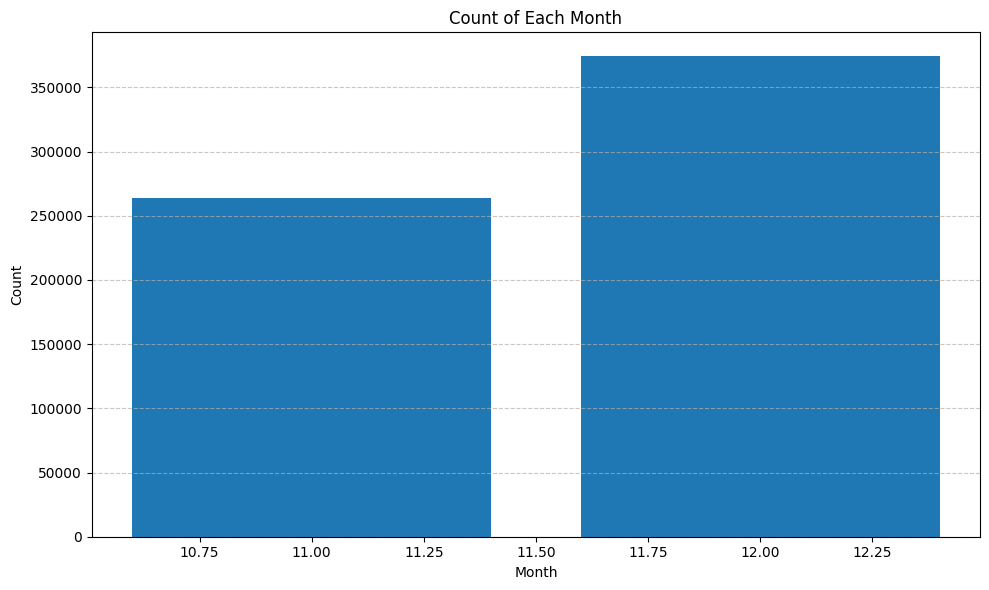

In [12]:

plot_bar('month')

It appears that we only have november and december in our month data. It means the data is only recorded or taken in november and december with december data dominating

    day  counts
0     1   41680
1     2   41297
2     3   41323
3     4   11627
4     9    1529
5    10    2534
6    13   35496
7    14   41344
8    15   41332
9    16   41359
10   17   41354
11   18   33329
12   26   29028
13   27   70135
14   28   67842
15   29   55222
16   30   41544


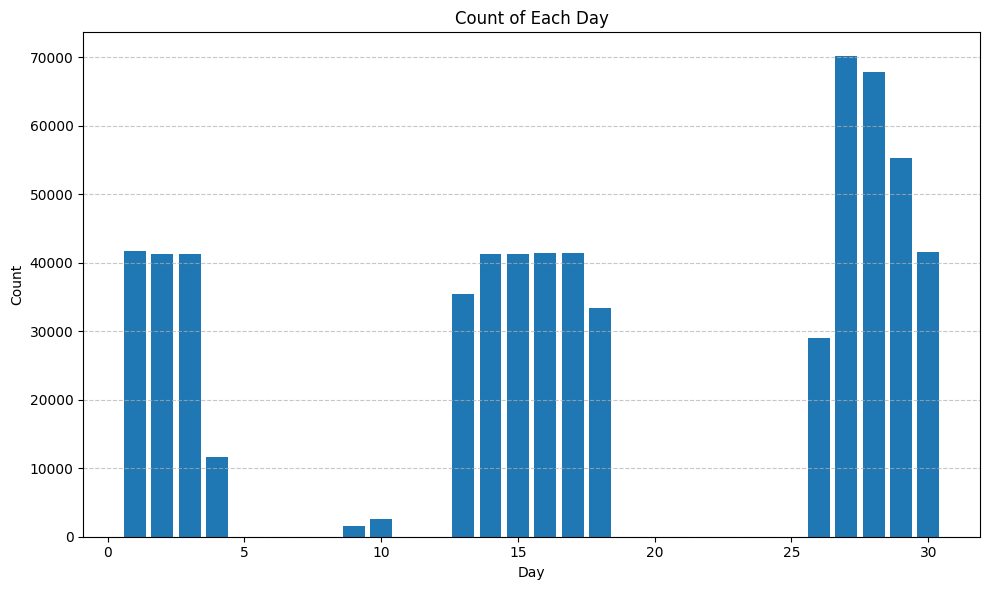

In [13]:
plot_bar('day')

It seems we have many gaps in our 'day' data. For example we don't have data from 18th day until 25th day in each month.

    hour  counts
0      0   29872
1      1   26309
2      2   26323
3      3   25530
4      4   26125
5      5   22995
6      6   25147
7      7   22930
8      8   22337
9      9   26673
10    10   27918
11    11   27946
12    12   28017
13    13   27977
14    14   27976
15    15   27868
16    16   27972
17    17   28075
18    18   27958
19    19   25410
20    20   24620
21    21   25549
22    22   27093
23    23   29355


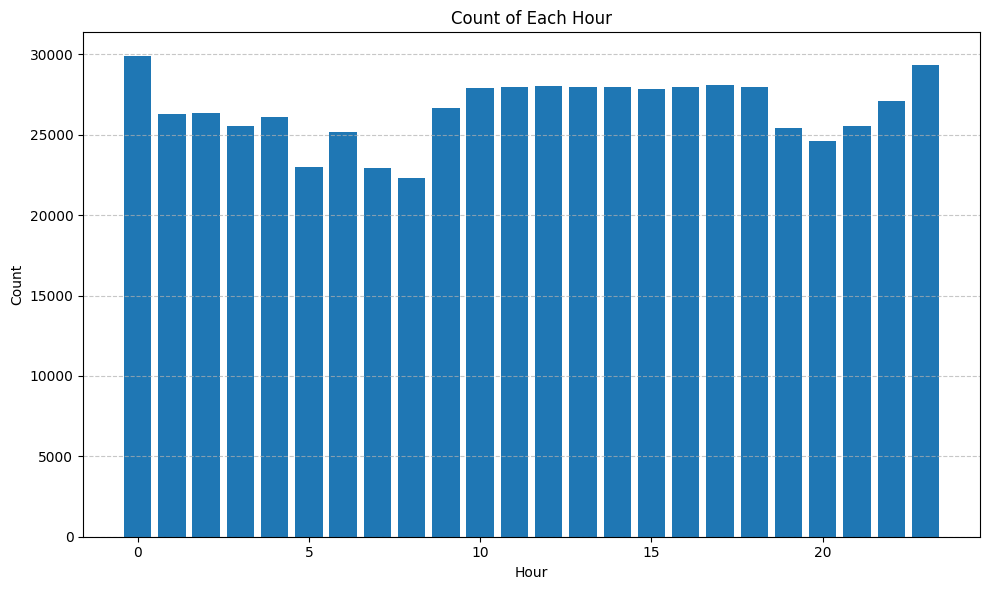

In [14]:
plot_bar('hour')

It seems we have almost 24 hours recorded data

### Source and Destination Analysis

In [15]:
def plot_bar(groupby_column):

    counts = df[groupby_column].value_counts().sort_index()

    print(counts.reset_index(name="counts").rename(columns={'index': groupby_column}))

    plt.figure(figsize=(10, 6))
    plt.bar(counts.index, counts.values)
    plt.xlabel(groupby_column.capitalize())
    plt.ylabel("Count")
    plt.title(f"Count of Each {groupby_column.capitalize()}")
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

                     source  counts
0                  Back Bay   53201
1               Beacon Hill   52841
2         Boston University   53172
3                    Fenway   53166
4        Financial District   54196
5          Haymarket Square   53147
6                 North End   53171
7             North Station   52576
8   Northeastern University   53164
9             South Station   53160
10         Theatre District   53201
11                 West End   52980


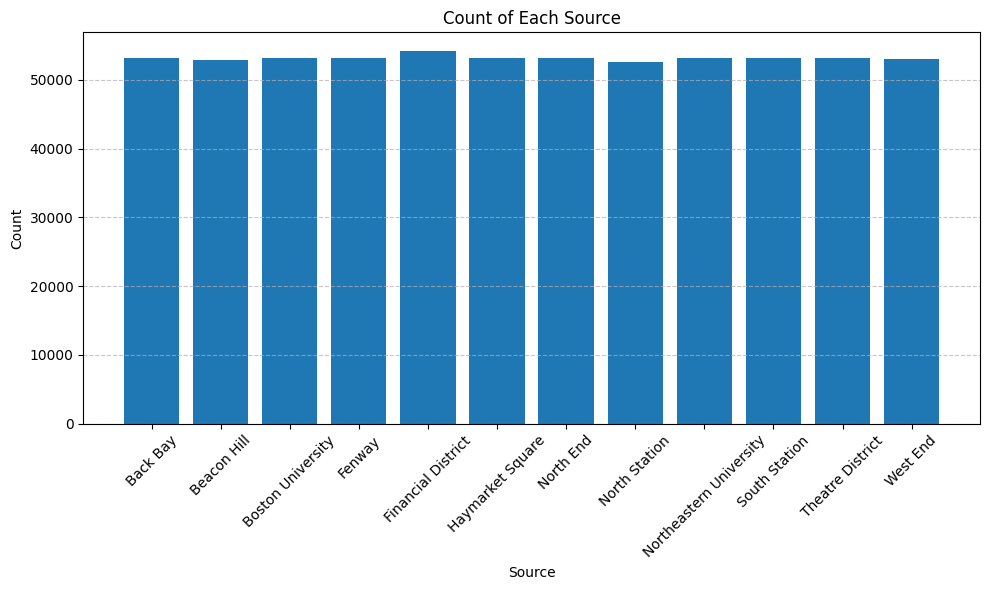

In [16]:
plot_bar('source')

It seems that all sources are almost equal in number. There are about 50k data in each source feature (Back Bay, Beacon Hill, Boston University, etc)

                destination  counts
0                  Back Bay   53190
1               Beacon Hill   52840
2         Boston University   53171
3                    Fenway   53165
4        Financial District   54192
5          Haymarket Square   53171
6                 North End   53164
7             North Station   52577
8   Northeastern University   53165
9             South Station   53159
10         Theatre District   53189
11                 West End   52992


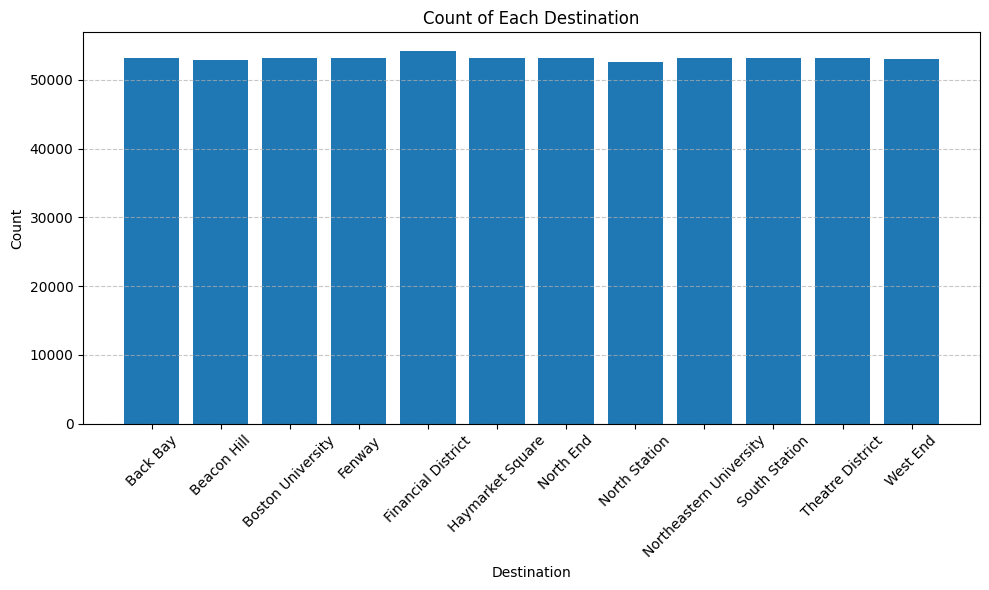

In [17]:
plot_bar('destination')

Same with source feature, there are about 50k data in each destination feature (Back Bay, Beacon Hill, Boston University, etc)

In [18]:
df.groupby(by=["destination","source"]).agg({'latitude':'mean','longitude':'mean'})

latitude  longitude
destination             source                                       
Back Bay                Boston University        42.336960 -71.066178
                        Fenway                   42.337740 -71.065822
                        Haymarket Square         42.337087 -71.065110
                        North End                42.338100 -71.066343
                        Northeastern University  42.336668 -71.065314
                        South Station            42.338897 -71.065908
Beacon Hill             Boston University        42.336917 -71.065885
                        Fenway                   42.338990 -71.065719
                        Haymarket Square         42.337413 -71.066059
                        North End                42.338418 -71.065809
                        Northeastern University  42.337268 -71.066061
                        South Station            42.336316 -71.065699
Boston University       Back Bay                 42.337217 -71.065947
                        Beacon Hill              42.339364 -71.066517
                        Financial District       42.339361 -71.066465
                        North Station            42.338372 -71.066191
                        Theatre District         42.338152 -71.066276
                        West End                 42.337556 -71.066265
Fenway                  Back Bay                 42.340103 -71.065819
                        Beacon Hill              42.337595 -71.065471
                        Financial District       42.337146 -71.066252
                        North Station            42.339660 -71.066504
                        Theatre District         42.336378 -71.065388
                        West End                 42.338521 -71.066339
Financial District      Boston University        42.338733 -71.066581
                        Fenway                   42.337034 -71.066028
                        Haymarket Square         42.337781 -71.065863
                        North End                42.338338 -71.065965
                        Northeastern University  42.338523 -71.065964
                        South Station            42.338989 -71.067037
Haymarket Square        Back Bay                 42.339877 -71.066475
                        Beacon Hill              42.337246 -71.065966
                        Financial District       42.337398 -71.066237
                        North Station            42.338276 -71.066073
                        Theatre District         42.338175 -71.065699
                        West End                 42.339109 -71.066251
North End               Back Bay                 42.338516 -71.066170
                        Beacon Hill              42.336792 -71.066216
                        Financial District       42.337654 -71.066158
                        North Station            42.339309 -71.066936
                        Theatre District         42.338578 -71.066639
                        West End                 42.338614 -71.065878
North Station           Boston University        42.338786 -71.066362
                        Fenway                   42.338450 -71.066614
                        Haymarket Square         42.337260 -71.066279
                        North End                42.337672 -71.065832
                        Northeastern University  42.337793 -71.066491
                        South Station            42.336529 -71.065432
Northeastern University Back Bay                 42.338917 -71.066289
                        Beacon Hill              42.339002 -71.065600
                        Financial District       42.337789 -71.066015
                        North Station            42.339770 -71.066493
                        Theatre District         42.338356 -71.065319
                        West End                 42.336812 -71.066274
South Station           Back Bay                 42.338567 -71.065891
                        Beacon Hill              42.338714 -

### Cab Type Analysis

  cab_type  counts
0     Lyft  307407
1     Uber  330568


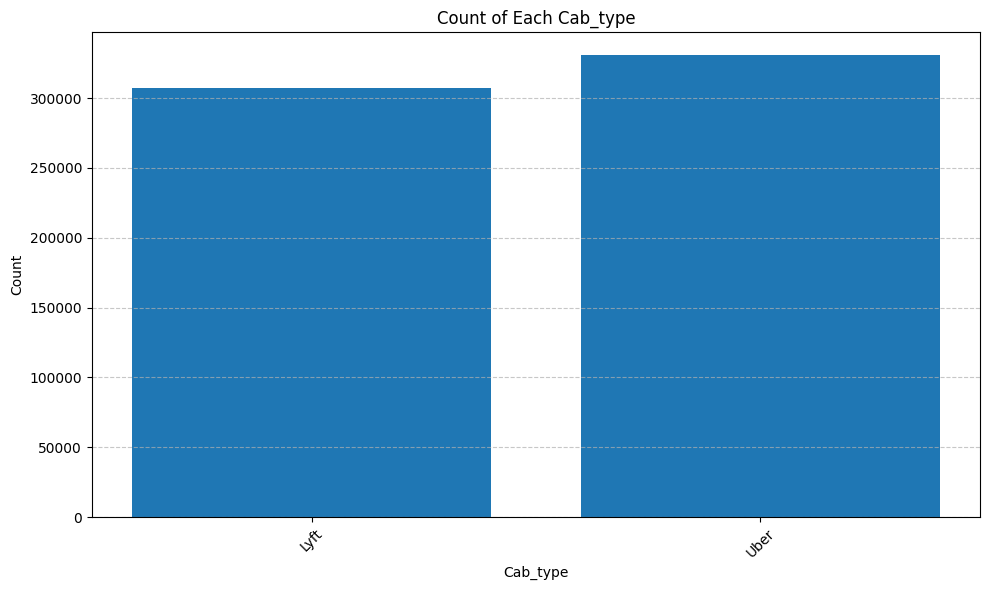

In [19]:
plot_bar('cab_type')

So for our whole data, we have uber data more than lyft data. The difference is not too big, each cab type has about 300K data

In [20]:
df2 =df.groupby(by=["day","cab_type"]).size().reset_index(name="counts")
fig2 = px.bar(data_frame=df2, x="day", y="counts", color="cab_type", barmode="group")
fig2.show()

In [21]:
df3 =df.groupby(["hour","cab_type"]).size().reset_index(name="counts")
fig3 = px.bar(data_frame=df3, x="hour", y="counts", color="cab_type", barmode="group")
fig3.show()

So in every day and every hour recorded, uber seems dominating booking order in our data

### Price Analysis

In [22]:
pd.set_option('display.max_rows', 72)
df.groupby(by=["source","destination"]).price.agg(["mean"])

mean
source                  destination                       
Back Bay                Boston University        14.039392
                        Fenway                   13.658752
                        Haymarket Square         17.987384
                        North End                19.473019
                        Northeastern University  13.151040
                        South Station            17.700711
Beacon Hill             Boston University        16.376737
                        Fenway                   16.158840
                        Haymarket Square         13.799137
                        North End                15.270942
                        Northeastern University  16.471792
                        South Station            15.950661
Boston University       Back Bay                 13.992801
                        Beacon Hill              17.315535
                        Financial District       24.146085
                        North Station            20.185338
                        Theatre District         18.689557
                        West End                 18.611766
Fenway                  Back Bay                 13.802155
                        Beacon Hill              16.796674
                        Financial District       23.438818
                        North Station            19.701839
                        Theatre District         18.232722
                        West End                 18.161806
Financial District      Boston University        25.498434
                        Fenway                   23.396550
                        Haymarket Square         13.188209
                        North End                13.179635
                        Northeastern University  21.918584
                        South Station            12.349066
Haymarket Square        Back Bay                 16.860489
                        Beacon Hill              13.338559
                        Financial District       12.731618
                        North Station            12.332545
                        Theatre District         13.677272
                        West End                 12.529855
North End               Back Bay                 19.550935
                        Beacon Hill              15.982630
                        Financial District       13.417597
                        North Station            12.824092
                        Theatre District         15.169406
                        West End                 13.494873
North Station           Boston University        18.931558
                        Fenway                   18.547603
                        Haymarket Square         12.571791
                        North End                13.106641
                        Northeastern University  19.537848
                        South Station            15.374198
Northeastern University Back Bay                 13.698923
                        Beacon Hill              16.842433
                        Financial District       22.582094
                        North Station            19.910939
                        Theatre District         16.144805
                        West End                 18.204155
South Station           Back Bay                 19.103822
                        Beacon Hill              17.276304
                        Financial District       12.436910
                        North Station            15.746736
                        Theatre District         13.952579
                        West End                 15.881172
Theatre District        Boston University        20.360662
                        Fenway                   19.069278
                        Haymarket Square         15.204973
                        North End                15.159646
                        Northeastern University  16.910751
                        South Station            12.888926
West End                Boston University 

We can see average or mean of our price data in every route (source-destination) through table above

In [23]:
print('Maximum price in our data :',df.price.max())
df[df['price']==df.price.max()]

Maximum price in our data : 92.0


,id,timestamp,hour,day,month,datetime,timezone,source,destination,cab_type,product_id,name,price,distance,surge_multiplier,latitude,longitude,temperature,apparentTemperature,short_summary,long_summary,precipIntensity,precipProbability,humidity,windSpeed,windGust,windGustTime,visibility,temperatureHigh,temperatureHighTime,temperatureLow,temperatureLowTime,apparentTemperatureHigh,apparentTemperatureHighTime,apparentTemperatureLow,apparentTemperatureLowTime,icon,dewPoint,pressure,windBearing,cloudCover,uvIndex,ozone,sunriseTime,sunsetTime,moonPhase,precipIntensityMax,uvIndexTime,temperatureMin,temperatureMinTime,temperatureMax,temperatureMaxTime,apparentTemperatureMin,apparentTemperatureMinTime,apparentTemperatureMax,apparentTemperatureMaxTime
28083,edb9ba13-b129-487f-be93-2e3abdd700a3,1.543441e+09,21,28,11,2018-11-28 21:41:35,America/New_York,Fenway,Financial District,Lyft,lyft_luxsuv,Lux Black XL,92.0,3.89,2.0,42.3519,-71.0551,41.35,35.62,Overcast,Mostly cloudy throughout the day.,0.0,0.0,0.60,9.29,11.60,1543431600,10.000,42.60,1543438800,37.33,1543489200,36.56,1543435200,31.82,1543478400,cloudy,28.39,993.87,295,1.00,0,355.2,1543405934,1543439719,0.72,0.0000,1543420800,33.70,1543399200,42.60,1543438800,29.88,1543399200,36.56,1543435200
75919,e0032a2b-c328-457e-adb5-79c3d83064a8,1.544721e+09,17,13,12,2018-12-13 17:15:14,America/New_York,Boston University,Financial District,Lyft,lyft_luxsuv,Lux Black XL,92.0,3.75,2.0,42.3644,-71.0661,31.24,31.24,Mostly Cloudy,Partly cloudy throughout the day.,0.0,0.0,0.54,2.50,3.20,1544738400,9.946,33.81,1544731200,27.05,1544781600,32.82,1544734800,27.70,1544781600,partly-cloudy-day,16.42,1033.89,18,0.69,1,327.2,1544702794,1544735602,0.21,0.0001,1544716800,17.91,1544688000,33.81,1544731200,13.47,1544688000,32.82,1544734800
271719,6f17623a-f97c-4379-9188-4f3e07d1c48e,1.543453e+09,1,29,11,2018-11-29 01:02:08,America/New_York,Financial District,Boston University,Lyft,lyft_luxsuv,Lux Black XL,92.0,5.39,2.0,42.3647,-71.0542,38.42,32.45,Mostly Cloudy,Mostly cloudy throughout the day.,0.0,0.0,0.72,8.41,11.54,1543431600,9.915,42.61,1543438800,37.60,1543489200,36.57,1543438800,32.12,1543478400,partly-cloudy-night,30.30,996.92,297,0.77,0,349.9,1543405936,1543439716,0.72,0.0000,1543420800,33.85,1543399200,42.61,1543438800,30.03,1543399200,36.57,1543438800
280566,fe9f56b5-e54a-48b4-b702-4e625adcf0ab,1.543356e+09,22,27,11,2018-11-27 22:03:21,America/New_York,Financial District,Boston University,Lyft,lyft_luxsuv,Lux Black XL,92.0,5.39,2.0,42.3519,-71.0643,40.88,35.55,Partly Cloudy,Light rain in the morning.,0.0,0.0,0.68,8.21,12.35,1543338000,10.000,46.72,1543320000,33.65,1543399200,43.70,1543320000,29.88,1543399200,partly-cloudy-night,31.21,991.29,247,0.28,0,307.6,1543319469,1543353347,0.68,0.1422,1543338000,35.90,1543377600,46.72,1543320000,31.81,1543377600,43.70,1543320000
301021,16373de7-5ef0-45a7-86d8-842bd12780e9,1.545090e+09,23,17,12,2018-12-17 23:45:13,America/New_York,Financial District,Boston University,Lyft,lyft_luxsuv,Lux Black XL,92.0,5.36,2.0,42.3559,-71.0550,38.96,33.83,Overcast,Light rain in the morning.,0.0,0.0,0.70,7.11,11.22,1545022800,9.955,41.41,1545076800,23.95,1545138000,35.91,1545076800,11.84,1545134400,cloudy,29.98,1000.88,294,0.92,0,376.8,1545048556,1545081259,0.33,0.0177,1545066000,34.18,1545044400,41.41,1545076800,28.19,1545044400,35.91,1545076800
440000,2a3f4de9-7a24-4580-8079-a7953a1431e3,1.543695e+09,20,1,12,2018-12-01 20:07:59,America/New_York,Financial District,Boston University,Lyft,lyft_luxsuv,Lux Black XL,92.0,5.37,2.0,42.3559,-71.0550,43.14,43.14,Mostly Cloudy,Light rain in the morning and overnight.,0.0,0.0,0.55,1.93,3.70,1543672800,9.661,44.76,1543690800,34.95,1543712400,44.09,1543690800,35.60,1543712400,partly-cloudy-day,27.88,1022.92,105,0.53,0,273.3,1543665330,1543698852,0.82,0.0000,1543683600,31.57,1543658400,44.76,1543690800,27.88,1543658400,44.09,1543690800
515785,75c1c9bf-38a7-4cb6-81c1-e2effaaaedbd,1.543338e+09,17,27,11,2018-11-27 17:03:22,America/New_York,Boston U

And we can see our maximum price data

In [24]:
df[df['price']==df.price.max()][['latitude','longitude']]

,latitude,longitude
28083,42.3519,-71.0551
75919,42.3644,-71.0661
271719,42.3647,-71.0542
280566,42.3519,-71.0643
301021,42.3559,-71.0550
440000,42.3559,-71.0550
515785,42.2148,-71.0330
537453,42.3559,-71.0550
560058,42.3661,-71.0631


In [25]:
import folium

map1 = folium.Map(location=(42.3503, -71.081), zoom_start=10)
folium.Marker(location=(42.3503, -71.081), popup="Fenway").add_to(map1)
folium.Marker(location=(42.3378, -71.066), popup="Financial District").add_to(map1)

map1


we can see  how far they are from each other ( they are both in Boston)

In [26]:
df_group = df.groupby(by=["source","destination"]).price.agg(["mean"]).reset_index()
df_group[(df_group['source']=='Financial District')& (df_group['destination']=='Fenway')]

,source,destination,mean
25,Financial District,Fenway,23.39655


The mean of the price data of that route is 23.4 dollars, which is far from our maximum price data (97.5 dollars). Then it is possible an outlier. We can drop it.

In [27]:
df = df.loc[df['price']!=df.price.max()]

In [28]:
# For further modelling i don't think we need date related features. But maybe we need them in the future analysis.
# so i will make new dataframe

new_df = df.drop(['id','timestamp','datetime','long_summary','apparentTemperatureHighTime','apparentTemperatureLowTime',
                  'apparentTemperatureLowTime','windGustTime','sunriseTime','sunsetTime','uvIndexTime','temperatureMinTime',
                 'temperatureMaxTime','apparentTemperatureMinTime','temperatureLowTime','apparentTemperatureMaxTime'],axis=1)
new_df.shape

(637966, 41)

Our goal is to make linear regression model. First we check correlation between our features and target feature (price)

First, i want to check the correlation of our temperature related features with our target feature (Price)¶

In [29]:
#test
from scipy.stats import pearsonr

temp_cols = [
    'temperature','apparentTemperature','temperatureHigh','temperatureLow',
    'apparentTemperatureHigh','apparentTemperatureLow','temperatureMin',
    'temperatureHighTime','temperatureMax','apparentTemperatureMin',
    'apparentTemperatureMax','price'
]

df_temp = new_df[temp_cols]

# Hypothesis testing: correlation between each temp feature and price
print("Hypothesis Test Results (H0: No correlation with price):\n")
for col in df_temp.columns:
    if col != 'price':
        corr, p_value = pearsonr(df_temp[col], df_temp['price'])
        print(f"{col:<30} | Correlation: {corr:.4f} | p-value: {p_value:.4f} | {'Reject H0' if p_value < 0.05 else 'Fail to Reject H0'}")


Hypothesis Test Results (H0: No correlation with price):

temperature                    | Correlation: -0.0001 | p-value: 0.9624 | Fail to Reject H0
apparentTemperature            | Correlation: -0.0002 | p-value: 0.8876 | Fail to Reject H0
temperatureHigh                | Correlation: -0.0005 | p-value: 0.7160 | Fail to Reject H0
temperatureLow                 | Correlation: 0.0002 | p-value: 0.8622 | Fail to Reject H0
apparentTemperatureHigh        | Correlation: -0.0002 | p-value: 0.8626 | Fail to Reject H0
apparentTemperatureLow         | Correlation: 0.0009 | p-value: 0.4948 | Fail to Reject H0
temperatureMin                 | Correlation: -0.0004 | p-value: 0.7600 | Fail to Reject H0
temperatureHighTime            | Correlation: 0.0008 | p-value: 0.5434 | Fail to Reject H0
temperatureMax                 | Correlation: -0.0005 | p-value: 0.7010 | Fail to Reject H0
apparentTemperatureMin         | Correlation: -0.0005 | p-value: 0.6737 | Fail to Reject H0
apparentTemperatureMax   

In [30]:
df_temp.head()

,temperature,apparentTemperature,temperatureHigh,temperatureLow,apparentTemperatureHigh,apparentTemperatureLow,temperatureMin,temperatureHighTime,temperatureMax,apparentTemperatureMin,apparentTemperatureMax,price
0,42.34,37.12,43.68,34.19,37.95,27.39,39.89,1544968800,43.68,33.73,38.07,5.0
1,43.58,37.35,47.30,42.10,43.92,36.20,40.49,1543251600,47.30,36.20,43.92,11.0
2,38.33,32.93,47.55,33.10,44.12,29.11,35.36,1543320000,47.55,31.04,44.12,7.0
3,34.38,29.63,45.03,28.90,38.53,26.20,34.67,1543510800,45.03,30.30,38.53,26.0
4,37.44,30.88,42.18,36.71,35.75,30.29,33.10,1543420800,42.18,29.11,35.75,9.0


<Axes: >

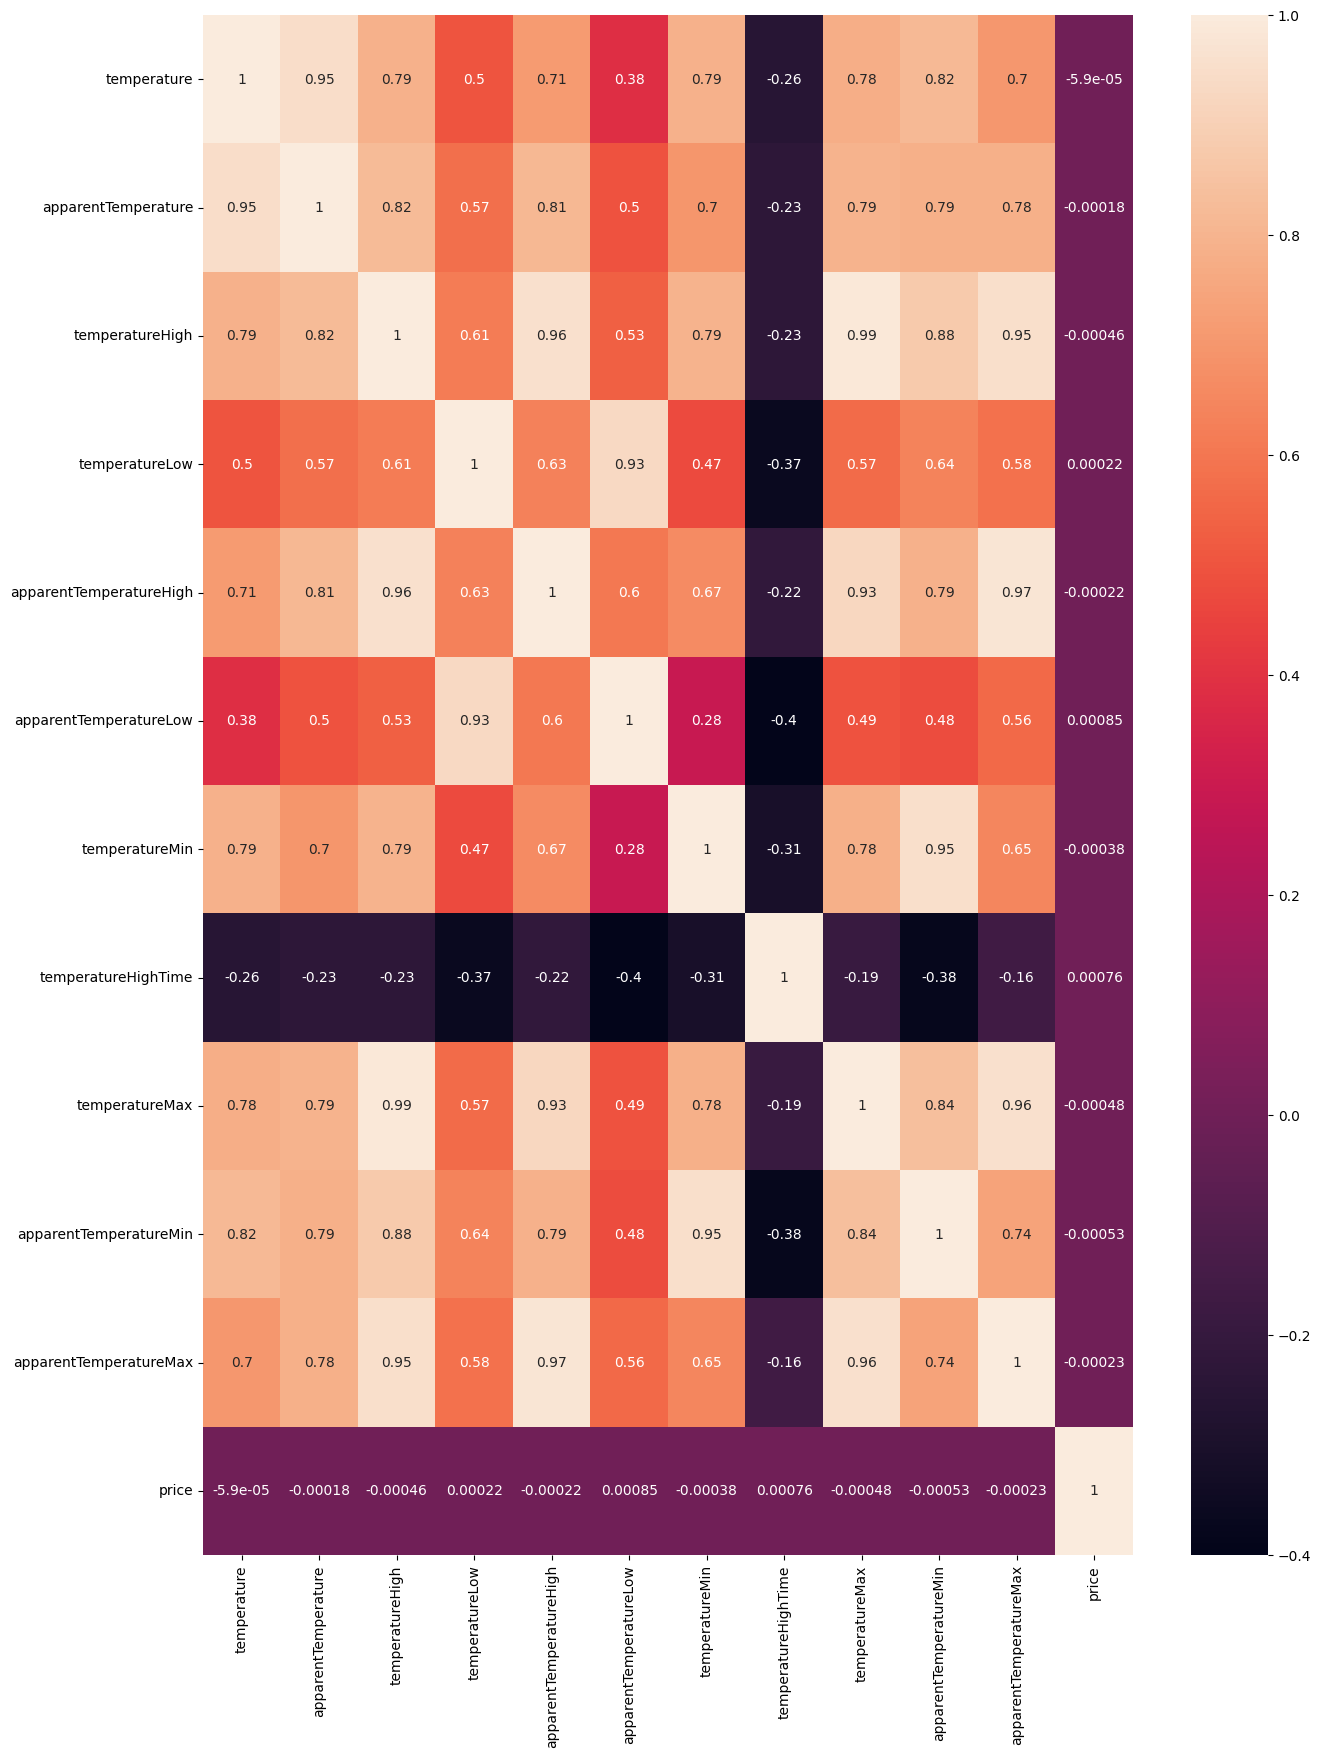

In [31]:
# visualization
plt.figure(figsize=(15,20))
sns.heatmap(df_temp.corr(),annot=True)

We see that all temperature related features have weak correlation with our target feature which is price. Removing all of them will not make any impact to our regression model¶


In [32]:
new_df = new_df.drop(['temperature','apparentTemperature','temperatureHigh','temperatureLow','apparentTemperatureHigh',
                'apparentTemperatureLow','temperatureMin','temperatureHighTime','temperatureMax','apparentTemperatureMin','apparentTemperatureMax'],axis=1)
new_df.shape

(637966, 30)

Second, i want to check the correlation of our cilmate related features with our target feature (Price)

In [33]:
#test
climate_column = [
    'precipIntensity', 'precipProbability', 'humidity', 'windSpeed',
    'windGust', 'visibility', 'dewPoint', 'pressure', 'windBearing',
    'cloudCover', 'uvIndex', 'ozone', 'moonPhase',
    'precipIntensityMax', 'price'
]

df_clim = new_df[climate_column]

# Hypothesis testing: correlation between each climate feature and price
print("Hypothesis Test Results (H0: No correlation with price):\n")
for col in df_clim.columns:
    if col != 'price':
        corr, p_value = pearsonr(df_clim[col], df_clim['price'])
        decision = 'Reject H0' if p_value < 0.05 else 'Fail to Reject H0'
        print(f"{col:<25} | Correlation: {corr:.4f} | p-value: {p_value:.4f} | {decision}")

Hypothesis Test Results (H0: No correlation with price):

precipIntensity           | Correlation: 0.0002 | p-value: 0.8677 | Fail to Reject H0
precipProbability         | Correlation: -0.0002 | p-value: 0.8819 | Fail to Reject H0
humidity                  | Correlation: -0.0012 | p-value: 0.3458 | Fail to Reject H0
windSpeed                 | Correlation: 0.0010 | p-value: 0.4242 | Fail to Reject H0
windGust                  | Correlation: 0.0012 | p-value: 0.3270 | Fail to Reject H0
visibility                | Correlation: 0.0014 | p-value: 0.2546 | Fail to Reject H0
dewPoint                  | Correlation: -0.0006 | p-value: 0.6497 | Fail to Reject H0
pressure                  | Correlation: 0.0009 | p-value: 0.4945 | Fail to Reject H0
windBearing               | Correlation: -0.0013 | p-value: 0.2837 | Fail to Reject H0
cloudCover                | Correlation: 0.0009 | p-value: 0.4711 | Fail to Reject H0
uvIndex                   | Correlation: -0.0004 | p-value: 0.7432 | Fail to R

In [34]:
df_clim.head()

,precipIntensity,precipProbability,humidity,windSpeed,windGust,visibility,dewPoint,pressure,windBearing,cloudCover,uvIndex,ozone,moonPhase,precipIntensityMax,price
0,0.0000,0.0,0.68,8.66,9.17,10.000,32.70,1021.98,57,0.72,0,303.8,0.30,0.1276,5.0
1,0.1299,1.0,0.94,11.98,11.98,4.786,41.83,1003.97,90,1.00,0,291.1,0.64,0.1300,11.0
2,0.0000,0.0,0.75,7.33,7.33,10.000,31.10,992.28,240,0.03,0,315.7,0.68,0.1064,7.0
3,0.0000,0.0,0.73,5.28,5.28,10.000,26.64,1013.73,310,0.00,0,291.1,0.75,0.0000,26.0
4,0.0000,0.0,0.70,9.14,9.14,10.000,28.61,998.36,303,0.44,0,347.7,0.72,0.0001,9.0


<Axes: >

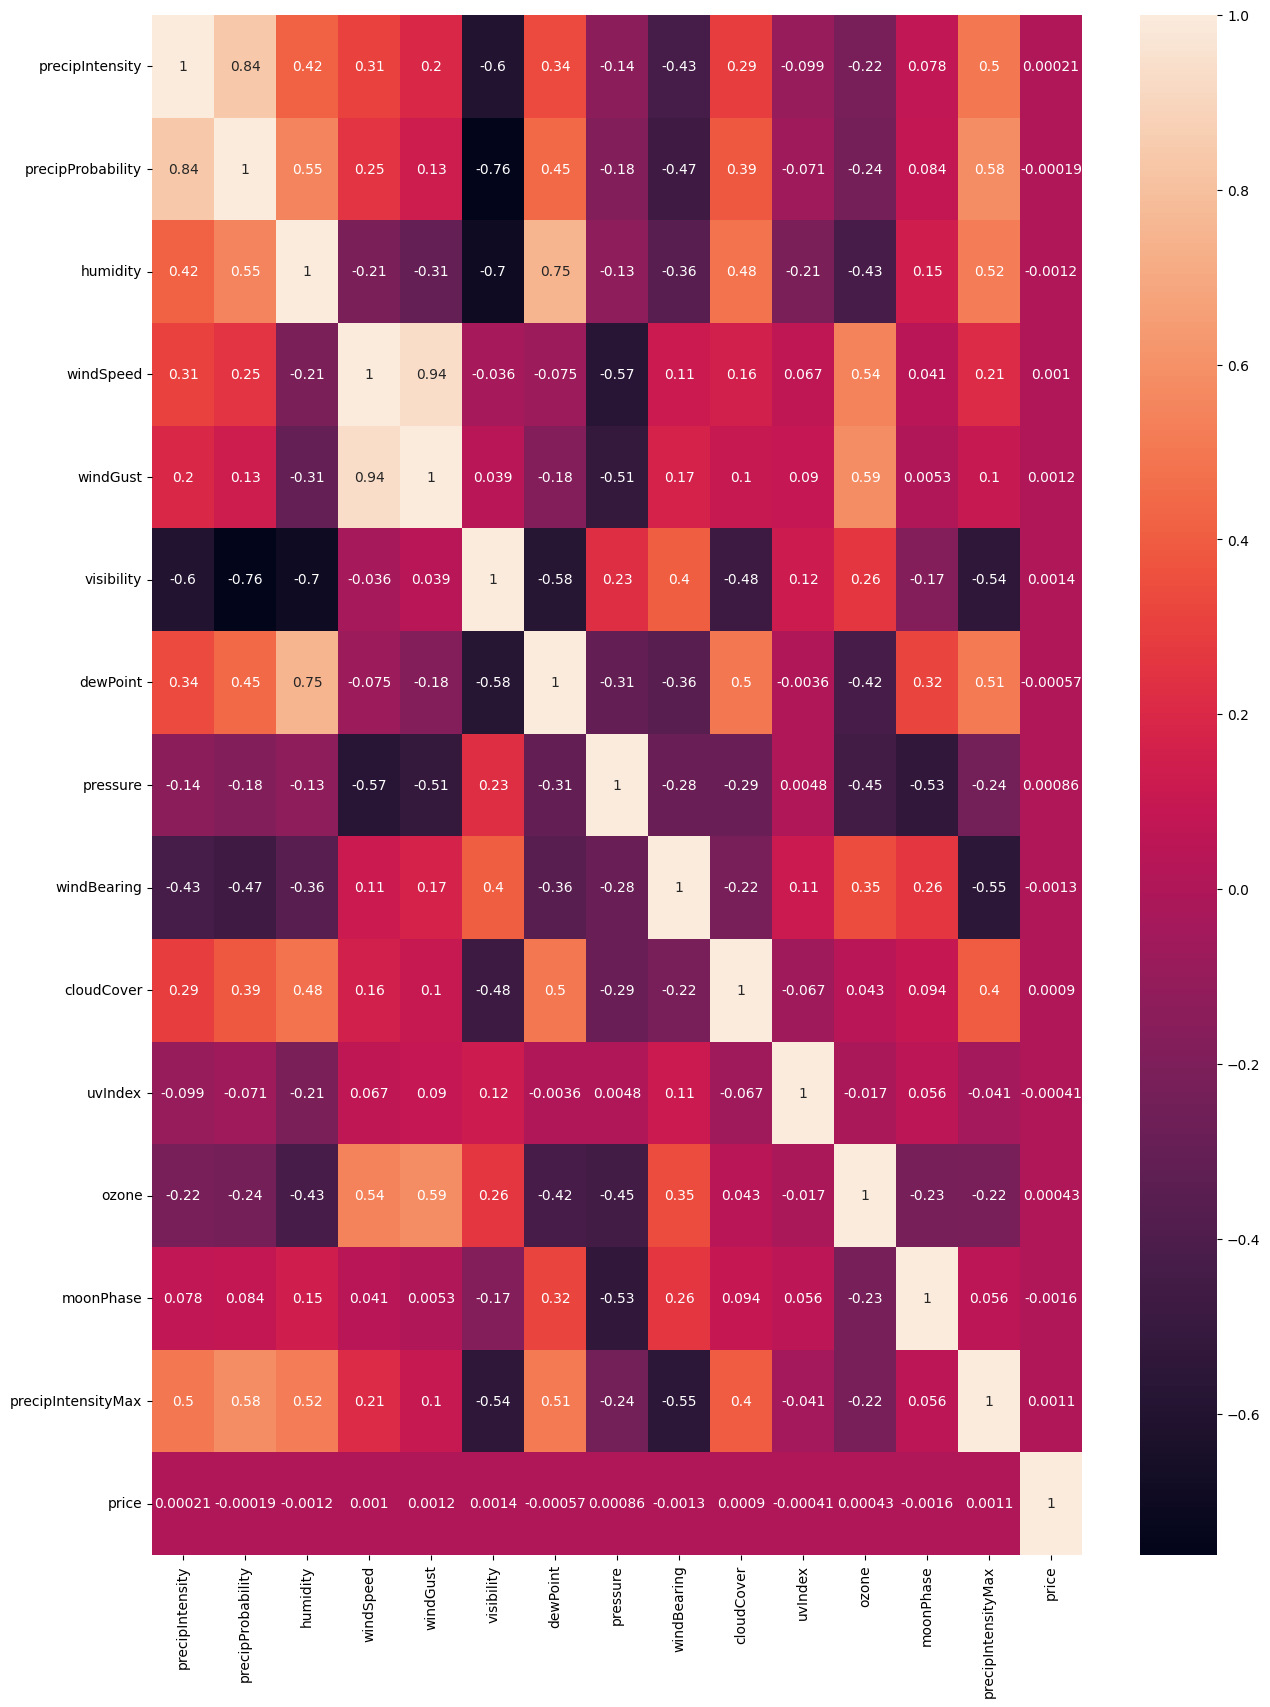

In [35]:
#visualization
plt.figure(figsize=(15,20))
sns.heatmap(df_clim.corr(),annot=True)

Apparently all climate related features also have weak correlation with our target feature which is price
Once again, removing all of them will not make any impact to our regression model

In [36]:
new_df = new_df.drop(['precipIntensity', 'precipProbability', 'humidity', 'windSpeed',
       'windGust', 'visibility', 'dewPoint', 'pressure', 'windBearing',
       'cloudCover', 'uvIndex', 'ozone', 'moonPhase',
       'precipIntensityMax'],axis=1)
new_df.shape

(637966, 16)

Third, i want to check our categorical value in our dataset features

In [37]:
category_col = new_df.select_dtypes(include=['object','category']).columns.tolist()
for column in new_df[category_col]:
    print(f'{column} : {new_df[column].unique()}')
    print()

timezone : ['America/New_York']

source : ['Haymarket Square' 'Back Bay' 'North End' 'North Station' 'Beacon Hill'
 'Boston University' 'Fenway' 'South Station' 'Theatre District'
 'West End' 'Financial District' 'Northeastern University']

destination : ['North Station' 'Northeastern University' 'West End' 'Haymarket Square'
 'South Station' 'Fenway' 'Theatre District' 'Beacon Hill' 'Back Bay'
 'North End' 'Financial District' 'Boston University']

cab_type : ['Lyft' 'Uber']

product_id : ['lyft_line' 'lyft_premier' 'lyft' 'lyft_luxsuv' 'lyft_plus' 'lyft_lux'
 '6f72dfc5-27f1-42e8-84db-ccc7a75f6969'
 '6c84fd89-3f11-4782-9b50-97c468b19529'
 '55c66225-fbe7-4fd5-9072-eab1ece5e23e'
 '9a0e7b09-b92b-4c41-9779-2ad22b4d779d'
 '6d318bcc-22a3-4af6-bddd-b409bfce1546'
 '997acbb5-e102-41e1-b155-9df7de0a73f2']

name : ['Shared' 'Lux' 'Lyft' 'Lux Black XL' 'Lyft XL' 'Lux Black' 'UberXL'
 'Black' 'UberX' 'WAV' 'Black SUV' 'UberPool']

short_summary : [' Mostly Cloudy ' ' Rain ' ' Clear ' ' Partly Clou

We can see that 'timezone' feature has only 1 value and 'product_id' feature contains many unidentified values. So we can remove or drop them.

In [38]:
new_df = new_df.drop(['timezone','product_id'],axis=1)

In [39]:
new_df.shape

(637966, 14)

Fourth, i want to check the correlation of our categorical features with our target feature (price)

In [40]:
new_cat = ['source',
 'destination',
 'cab_type',
 'name',
 'short_summary',
 'icon','price']

df_cat = new_df[new_cat]
df_cat.head()

,source,destination,cab_type,name,short_summary,icon,price
0,Haymarket Square,North Station,Lyft,Shared,Mostly Cloudy,partly-cloudy-night,5.0
1,Haymarket Square,North Station,Lyft,Lux,Rain,rain,11.0
2,Haymarket Square,North Station,Lyft,Lyft,Clear,clear-night,7.0
3,Haymarket Square,North Station,Lyft,Lux Black XL,Clear,clear-night,26.0
4,Haymarket Square,North Station,Lyft,Lyft XL,Partly Cloudy,partly-cloudy-night,9.0


In [41]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()

df_cat_encode= df_cat.copy()
for col in df_cat_encode.select_dtypes(include='O').columns:
    df_cat_encode[col]=le.fit_transform(df_cat_encode[col])

In [42]:
df_cat_encode

,source,destination,cab_type,name,short_summary,icon,price
0,5,7,0,7,4,5,5.0
1,5,7,0,2,8,6,11.0
2,5,7,0,5,0,1,7.0
3,5,7,0,4,0,1,26.0
4,5,7,0,6,6,5,9.0
...,...,...,...,...,...,...,...
693065,11,6,1,11,6,5,9.5
693066,11,6,1,10,6,5,13.0
693067,11,6,1,9,6,5,9.5
693069,11,6,1,1,6,5,27.0


<Axes: >

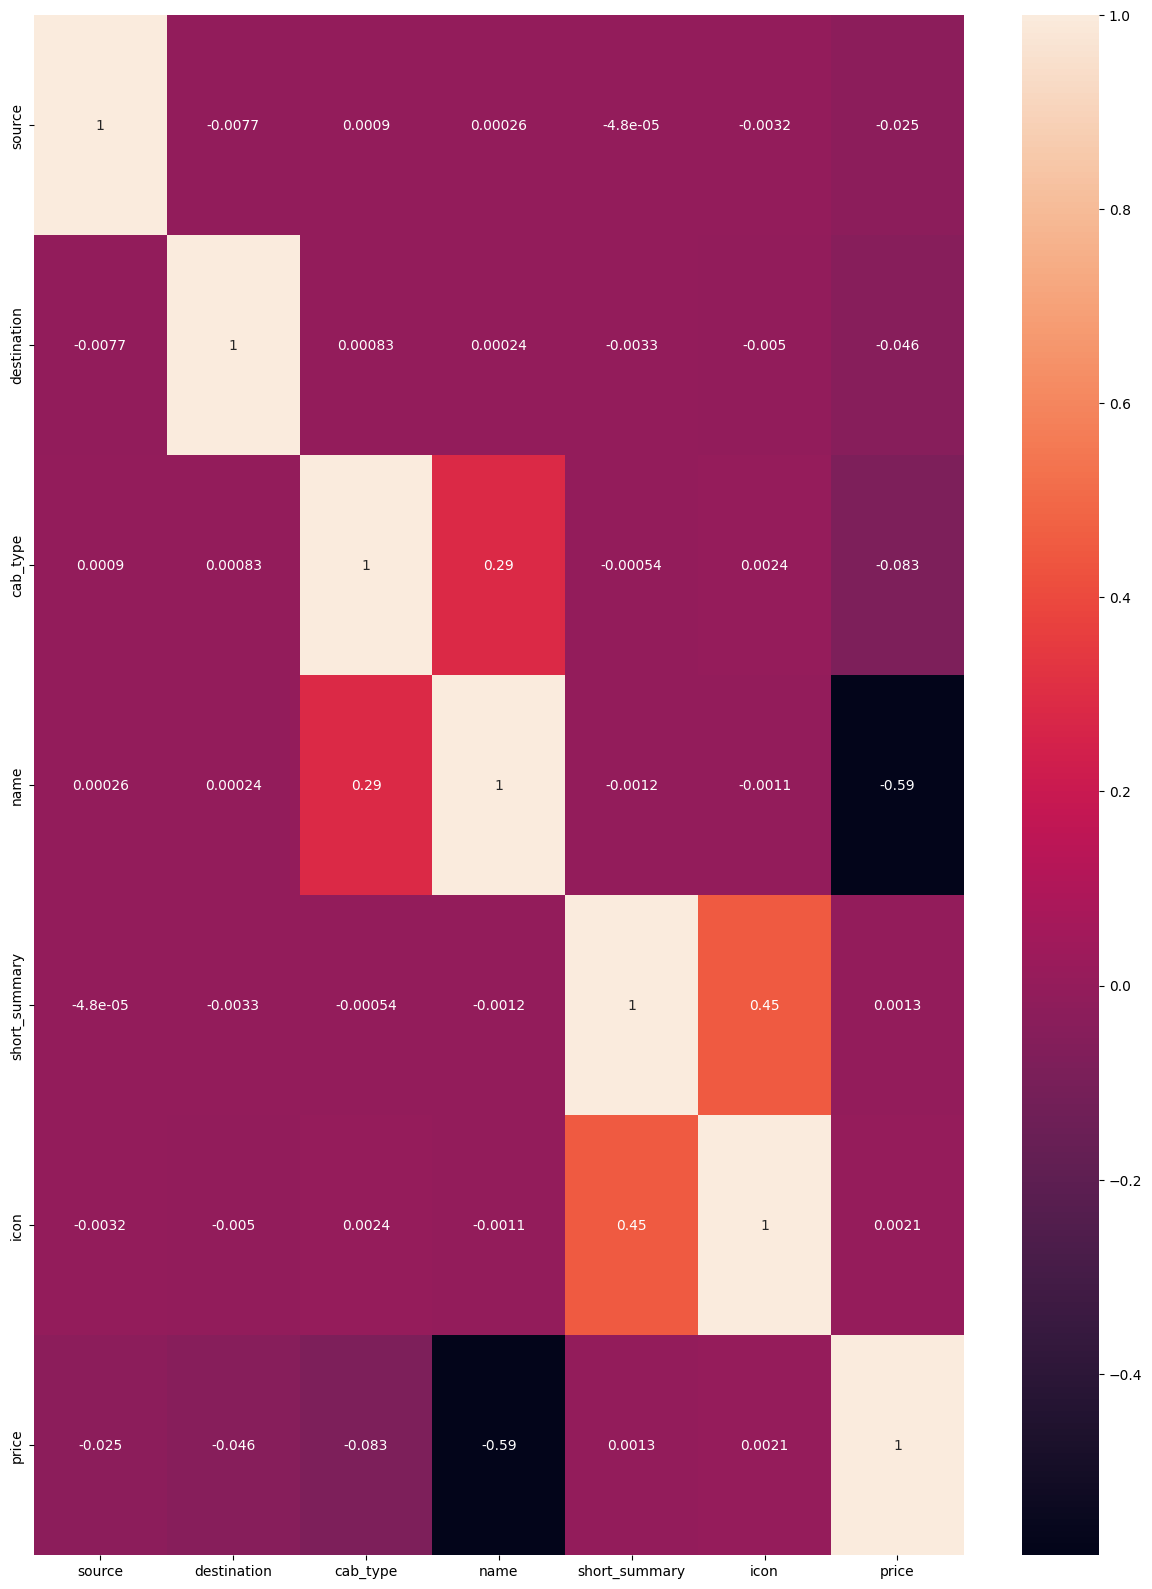

In [43]:
plt.figure(figsize=(15,20))
sns.heatmap(df_cat_encode.corr(),annot=True)

We can see only name feature that has a relatively strong correlation. Source,destination, and cab_type features have relatively weak correlation, but i will pick cab_type feature because it has stronger correlation than other two features. I will drop or remove the rest of the columns¶

In [44]:
new_df = new_df.drop(['source','destination','short_summary','icon'],axis=1)
new_df.head()

,hour,day,month,cab_type,name,price,distance,surge_multiplier,latitude,longitude
0,9,16,12,Lyft,Shared,5.0,0.44,1.0,42.2148,-71.033
1,2,27,11,Lyft,Lux,11.0,0.44,1.0,42.2148,-71.033
2,1,28,11,Lyft,Lyft,7.0,0.44,1.0,42.2148,-71.033
3,4,30,11,Lyft,Lux Black XL,26.0,0.44,1.0,42.2148,-71.033
4,3,29,11,Lyft,Lyft XL,9.0,0.44,1.0,42.2148,-71.033


Also i will remove hour, day, month, latitude, longitude, because we won't need them for now

In [45]:
new_df = new_df.drop(['hour','day','month','latitude','longitude'],axis=1)
new_df.head()

,cab_type,name,price,distance,surge_multiplier
0,Lyft,Shared,5.0,0.44,1.0
1,Lyft,Lux,11.0,0.44,1.0
2,Lyft,Lyft,7.0,0.44,1.0
3,Lyft,Lux Black XL,26.0,0.44,1.0
4,Lyft,Lyft XL,9.0,0.44,1.0


In [46]:
new_df.columns

Index(['cab_type', 'name', 'price', 'distance', 'surge_multiplier'], dtype='object')

Now I chack the outliers and remove them

In [47]:
Qp12 = new_df['price'].quantile(0.25)
Qp32 = new_df['price'].quantile(0.75)
IQRp = Qp32-Qp12
new_df[new_df['price']>(Qp32+(1.5*IQRp))]


,cab_type,name,price,distance,surge_multiplier
706,Lyft,Lux Black,52.5,3.25,2.00
707,Lyft,Lux Black XL,67.5,3.25,2.00
769,Lyft,Lux Black XL,45.5,4.76,1.00
1094,Lyft,Lux Black XL,45.5,4.31,1.00
1318,Lyft,Lux Black XL,45.5,5.33,1.00
...,...,...,...,...,...
692439,Uber,Black SUV,47.0,5.56,1.00
692698,Lyft,Lux Black XL,52.5,4.58,1.25
692891,Lyft,Lux Black XL,47.5,5.42,1.00
692962,Uber,Black SUV,51.0,7.36,1.00


In [48]:
new_df[new_df['price']<(Qp12-(1.5*IQRp))]

,cab_type,name,price,distance,surge_multiplier


we have 5588 data outliers. We can remove or drop them.

In [49]:
print('Size before removing :',new_df.shape)
new_df= new_df[~((new_df['price']>(Qp32+(1.5*IQRp))))]
print('Size after removing :',new_df.shape)

Size before removing : (637966, 5)
Size after removing : (632387, 5)


## 2. Baseline Linear Regression

In [50]:
# Encoding Data (One Hot Encoding)
def one_hot_encoder(data,feature,keep_first=True):

    one_hot_cols = pd.get_dummies(data[feature])

    for col in one_hot_cols.columns:
        one_hot_cols.rename({col:f'{feature}_'+col},axis=1,inplace=True)

    new_data = pd.concat([data,one_hot_cols],axis=1)
    new_data.drop(feature,axis=1,inplace=True)

    if keep_first == False:
        new_data=new_data.iloc[:,1:]

    return new_data

In [51]:
new_df_onehot=new_df.copy()
for col in new_df_onehot.select_dtypes(include='O').columns:
    new_df_onehot=one_hot_encoder(new_df_onehot,col)

new_df_onehot.head()

,price,distance,surge_multiplier,cab_type_Lyft,cab_type_Uber,name_Black,name_Black SUV,name_Lux,name_Lux Black,name_Lux Black XL,name_Lyft,name_Lyft XL,name_Shared,name_UberPool,name_UberX,name_UberXL,name_WAV
0,5.0,0.44,1.0,True,False,False,False,False,False,False,False,False,True,False,False,False,False
1,11.0,0.44,1.0,True,False,False,False,True,False,False,False,False,False,False,False,False,False
2,7.0,0.44,1.0,True,False,False,False,False,False,False,True,False,False,False,False,False,False
3,26.0,0.44,1.0,True,False,False,False,False,False,True,False,False,False,False,False,False,False
4,9.0,0.44,1.0,True,False,False,False,False,False,False,False,True,False,False,False,False,False


In [52]:
# Dataset Split

# Keep feature names before converting to .values
feature_names = new_df_onehot.drop(columns=['price'], axis=1).columns

X = new_df_onehot.drop(columns=['price'],axis=1).values
y = new_df_onehot['price'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [53]:
# Modeling


reg = LinearRegression()

In [54]:
# Fit to data training
model = reg.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [55]:
# Model Evaluation

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² (Coefficient of Determination): {r2:.4f}")


Mean Absolute Error (MAE): 1.67
Mean Squared Error (MSE): 5.08
R² (Coefficient of Determination): 0.9343


we understand that:


The model is accurate and generalizes well on the test set.

Errors are small on average, and prediction variance aligns closely with actual data.

If this is test set performance, it likely indicates no major overfitting and that features are well-explained by a linear relationship.

 we still can improve it with other regression models which could give better results.

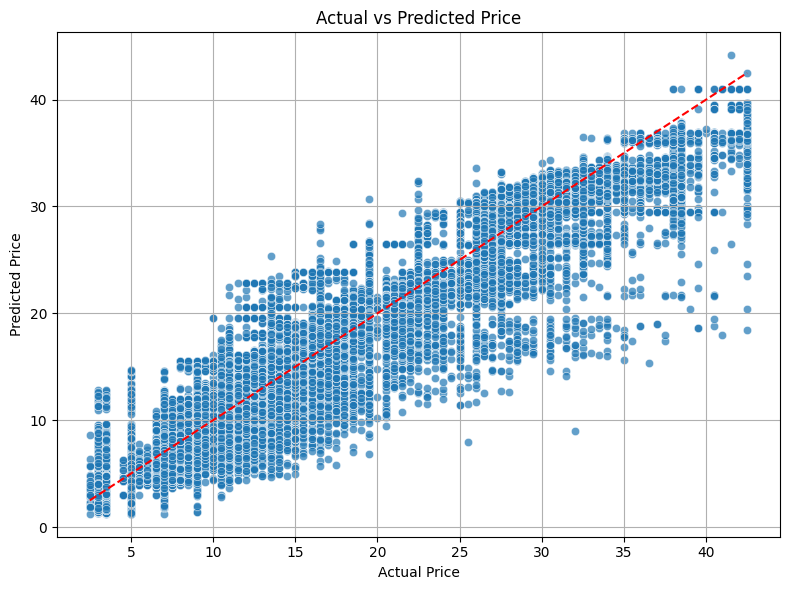

In [56]:
# Scatter Plot: Actual vs Predicted
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # identity line
plt.grid(True)
plt.tight_layout()
plt.show()


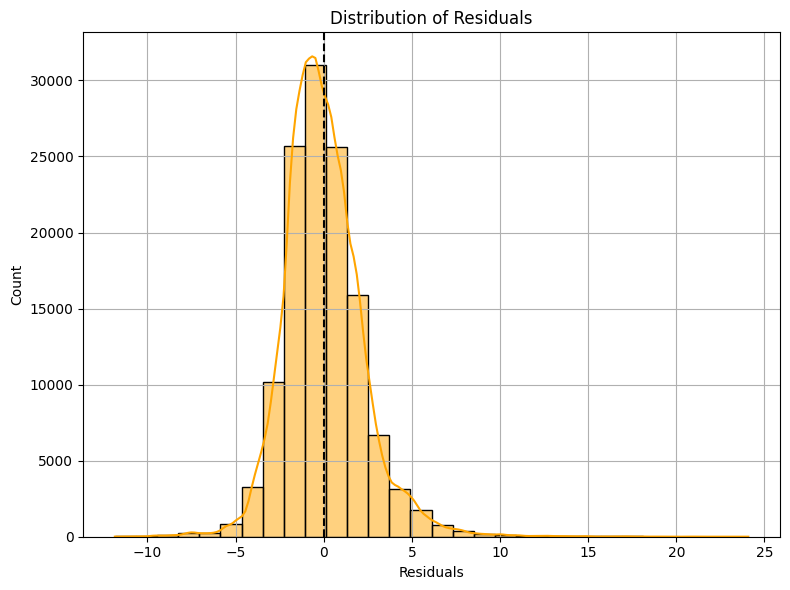

In [57]:
# Residual Plot
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
sns.histplot(residuals, bins=30, kde=True, color='orange')
plt.axvline(0, color='black', linestyle='--')
plt.xlabel("Residuals")
plt.title("Distribution of Residuals")
plt.grid(True)
plt.tight_layout()
plt.show()


<ipython-input-58-2b2e37bad354>:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




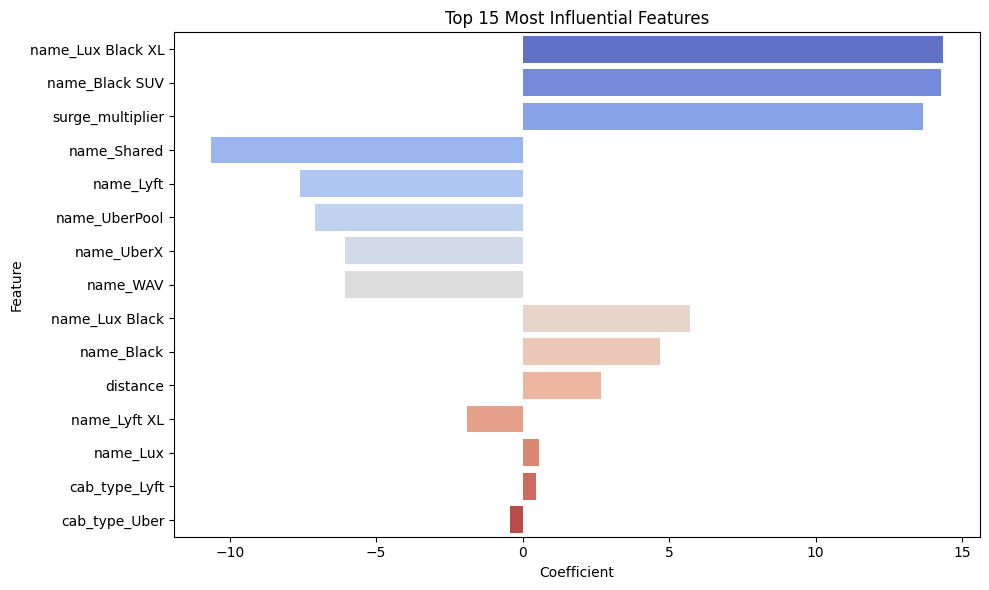

              Feature  Coefficient
8   name_Lux Black XL    14.355062
5      name_Black SUV    14.263109
1    surge_multiplier    13.668507
11        name_Shared   -10.648867
9           name_Lyft    -7.600973
12      name_UberPool    -7.072731
13         name_UberX    -6.063243
15           name_WAV    -6.062426
7      name_Lux Black     5.696054
4          name_Black     4.678146
0            distance     2.669164
10       name_Lyft XL    -1.905249
6            name_Lux     0.542130
2       cab_type_Lyft     0.438157
3       cab_type_Uber    -0.438157


In [58]:
# Interpretation of Coefficients
# Assuming X_train is a DataFrame with column names

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

# Plotting

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df.head(15), palette='coolwarm')
plt.title("Top 15 Most Influential Features")
plt.tight_layout()
plt.show()

print(coef_df.head(15))



## 3. Model Variants and Nonlinear Extensions

In [59]:

# It's important to scale features for regularized models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Ridge

In [60]:


# Define a range of alphas
alphas = np.logspace(-3, 3, 100)

ridge_cv = RidgeCV(alphas=alphas, scoring='r2', cv=5)
ridge_cv.fit(X_train_scaled, y_train)

best_alpha_ridge = ridge_cv.alpha_
print(f"Best alpha for Ridge: {best_alpha_ridge:.5f}")

# Retrain Ridge with best alpha
ridge_best = Ridge(alpha=best_alpha_ridge)
ridge_best.fit(X_train_scaled, y_train)
ridge_preds = ridge_best.predict(X_test_scaled)

# Evaluation
ridge_mae = mean_absolute_error(y_test, ridge_preds)
ridge_mse = mean_squared_error(y_test, ridge_preds)
ridge_r2 = r2_score(y_test, ridge_preds)

print("\nRidge Regression Evaluation:")
print(f"MAE: {ridge_mae:.2f}")
print(f"MSE: {ridge_mse:.2f}")
print(f"R²: {ridge_r2:.4f}")


Best alpha for Ridge: 1.62975

Ridge Regression Evaluation:
MAE: 1.67
MSE: 5.08
R²: 0.9343


As we can see the evaluation metrics are the same to the baseline model.

Lasso

In [61]:


lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train)

best_alpha_lasso = lasso_cv.alpha_
print(f"Best alpha for Lasso: {best_alpha_lasso:.5f}")

# Retrain Lasso with best alpha
lasso_best = Lasso(alpha=best_alpha_lasso)
lasso_best.fit(X_train_scaled, y_train)
lasso_preds = lasso_best.predict(X_test_scaled)

# Evaluation
lasso_mae = mean_absolute_error(y_test, lasso_preds)
lasso_mse = mean_squared_error(y_test, lasso_preds)
lasso_r2 = r2_score(y_test, lasso_preds)

print("\nLasso Regression Evaluation:")
print(f"MAE: {lasso_mae:.2f}")
print(f"MSE: {lasso_mse:.2f}")
print(f"R²: {lasso_r2:.4f}")


Best alpha for Lasso: 0.00100

Lasso Regression Evaluation:
MAE: 1.67
MSE: 5.08
R²: 0.9342


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning:

Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.220e+04, tolerance: 3.886e+03



As we can see the evaluation metrics are the same to the baseline model

We conclude that the results from Ridge, Lasso and the baseline model are the same.

Polynomial (degree = 2)

In [62]:



# 1. Polynomial transformation
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# 2. Train-test split
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly, y, test_size=0.2, random_state=0)

# 3. Feature scaling
scaler_poly = StandardScaler()
X_train_poly_scaled = scaler_poly.fit_transform(X_train_poly)
X_test_poly_scaled = scaler_poly.transform(X_test_poly)

# 4. Fit linear model to polynomial features
poly_model = LinearRegression()
poly_model.fit(X_train_poly_scaled, y_train_poly)
y_pred_poly = poly_model.predict(X_test_poly_scaled)

# 5. Evaluate performance
mae_poly = mean_absolute_error(y_test_poly, y_pred_poly)
mse_poly = mean_squared_error(y_test_poly, y_pred_poly)
r2_poly = r2_score(y_test_poly, y_pred_poly)

print(f"Polynomial Regression (degree 2) Results:")
print(f"MAE: {mae_poly:.2f}")
print(f"MSE: {mse_poly:.2f}")
print(f"R²:  {r2_poly:.4f}")


Polynomial Regression (degree 2) Results:
MAE: 1.26
MSE: 3.19
R²:  0.9587


we see a little bit of improvement but not very considerable.

**Trade-Offs**

\
1.Model Complexity

Linear Regression is most basic it can only fit linear lines.

Ridge/Lasso add regularization and lower complexity by penalizing coefficients (particularly Lasso, which can set coefficients to zero).

Polynomial Regression has much greater complexity it more features and chances of overfitting.

\
2.Performance

based on the metrics, (MAE, MSE, R^2) :

Polynomial regression has minimum error but is likely to overfit.

Ridge and Lasso offer small performance gain in general but in here they were almost identical with the baseline model and they also handle complexity.

\

3.Interpretability

Linear Regression: Very interpretable its coefficients represent simple feature effect.

Ridge/Lasso: Coefficients are shrunk or dropped, so Lasso is especially well-adapted to feature selection.

Polynomial Regression: Low interpretability its interactions and squared terms make it difficult to explain to stakeholders.



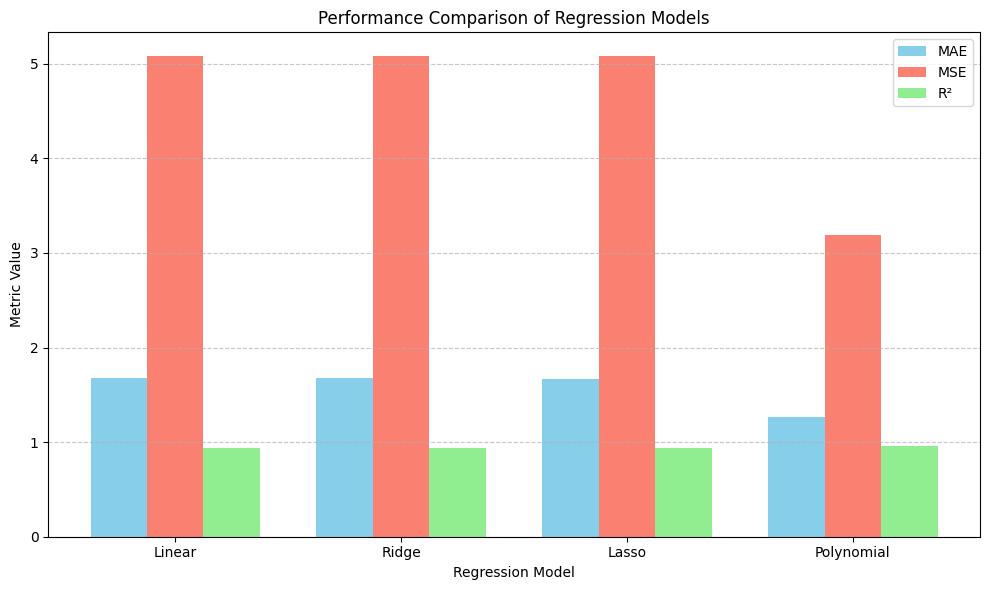

In [63]:


models = ['Linear', 'Ridge', 'Lasso', 'Polynomial']

# Performance metrics
mae_values = [mae, ridge_mae, lasso_mae, mae_poly]
mse_values = [mse, ridge_mse, lasso_mse, mse_poly]
r2_values  = [r2, ridge_r2, lasso_r2, r2_poly]

# Grouped bar chart setup
x = np.arange(len(models))
width = 0.25

# plot
fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width, mae_values, width, label='MAE', color='skyblue')
bars2 = ax.bar(x, mse_values, width, label='MSE', color='salmon')
bars3 = ax.bar(x + width, r2_values, width, label='R²', color='lightgreen')

ax.set_xlabel('Regression Model')
ax.set_ylabel('Metric Value')
ax.set_title('Performance Comparison of Regression Models')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


| Metric | Observation |
|--------|-------------|
| **MAE (Mean Absolute Error)** | Polynomial Regression has the lowest MAE, indicating better average prediction accuracy than the others. Linear, Ridge, and Lasso have nearly identical and higher MAE values. |
| **MSE (Mean Squared Error)** | Polynomial Regression significantly reduces the MSE, suggesting it handles outliers or large errors better than the linear models. The other three models have similar and notably higher MSEs. |
| **R² (Coefficient of Determination)** | All models have very similar and high R² scores (close to 1), suggesting they all explain a similar proportion of the variance in the data, but Polynomial is slightly better. |

| Aspect | Polynomial Regression | Linear/Ridge/Lasso |
|--------|------------------------|---------------------|
| **Complexity** | Higher (due to added polynomial features) | Lower (simpler models) |
| **Performance** | Better (lower MAE/MSE, higher R²) | Worse (especially in MSE) |
| **Interpretability** | Lower (harder to interpret higher-degree terms) | Higher (coefficients directly tied to features) |
| **Overfitting Risk** | Increased if degree is too high | Lower, especially with Ridge/Lasso regularization |

Conclusion


Polynomial Regression outperforms the others in terms of error reduction and maintains high R².

but it has less interpretability and can risk overfitting if not properly regularized or validated.

For high stakes or interpretable scenarios Ridge or Lasso are better tradeoffs.

For  tasks that accuracy is more important and complexity is ok, Polynomial Regression is a good option.

## 4. Model Enhancement through Data Preparation

In [64]:
# Target Encoding + Interaction Terms + Outlier Filtering (Isolation Forest)
from itertools import combinations
from sklearn.ensemble import IsolationForest

# Keep only the specified features
features_to_keep = ['cab_type', 'name', 'distance', 'surge_multiplier', 'price']
df_clean = df[features_to_keep].copy()

# Target encoding for cab_type and name based on price
for col in ['cab_type', 'name']:
    target_means = df_clean.groupby(col)['price'].mean()
    df_clean[f'{col}_te'] = df_clean[col].map(target_means)

#  Build interaction terms ( among distance, surge_multiplier, cab_type_te, name_te)
interaction_cols = ['distance', 'surge_multiplier', 'cab_type_te', 'name_te']
for col1, col2 in combinations(interaction_cols, 2):
    df_clean[f'{col1}_x_{col2}'] = df_clean[col1] * df_clean[col2]

#  Drop original categorical columns and keep only engineered features
df_model = df_clean.drop(columns=['cab_type', 'name'])

#  Outlier filtering using Isolation Forest
iso = IsolationForest(contamination=0.01, random_state=42)
outlier_preds = iso.fit_predict(df_model.drop(columns=['price']))
df_model['is_outlier'] = outlier_preds
df_model = df_model[df_model['is_outlier'] == 1].drop(columns=['is_outlier'])


print(f"Final shape: {df_model.shape}")
df_model.head()


Final shape: (631613, 11)


,distance,surge_multiplier,price,cab_type_te,name_te,distance_x_surge_multiplier,distance_x_cab_type_te,distance_x_name_te,surge_multiplier_x_cab_type_te,surge_multiplier_x_name_te,cab_type_te_x_name_te
0,0.44,1.0,5.0,17.34895,6.029893,0.44,7.633538,2.653153,17.34895,6.029893,104.612308
1,0.44,1.0,11.0,17.34895,17.771240,0.44,7.633538,7.819346,17.34895,17.771240,308.312357
2,0.44,1.0,7.0,17.34895,9.610885,0.44,7.633538,4.228789,17.34895,9.610885,166.738757
3,0.44,1.0,26.0,17.34895,32.312329,0.44,7.633538,14.217425,17.34895,32.312329,560.584974
4,0.44,1.0,9.0,17.34895,15.309363,0.44,7.633538,6.736120,17.34895,15.309363,265.601366


In [65]:


# Keep feature names before converting to .values
feature_names = df_model.drop(columns=['price'], axis=1).columns

# Prepare the feature matrix (X) and target vector (y)
X = df_model.drop(columns=['price'], axis=1).values
y = df_model['price'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Polynomial feature transformation
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Feature scaling
scaler_poly = StandardScaler()
X_train_poly_scaled = scaler_poly.fit_transform(X_train_poly)
X_test_poly_scaled = scaler_poly.transform(X_test_poly)

# Fit linear regression model
poly_model = LinearRegression()
poly_model.fit(X_train_poly_scaled, y_train)
y_pred_poly = poly_model.predict(X_test_poly_scaled)

# Evaluate model performance
mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print(f"Polynomial Regression (degree 2) Results:")
print(f"MAE: {mae_poly:.2f}")
print(f"MSE: {mse_poly:.2f}")
print(f"R²:  {r2_poly:.4f}")


Polynomial Regression (degree 2) Results:
MAE: 1.26
MSE: 3.32
R²:  0.9582


## Bonus

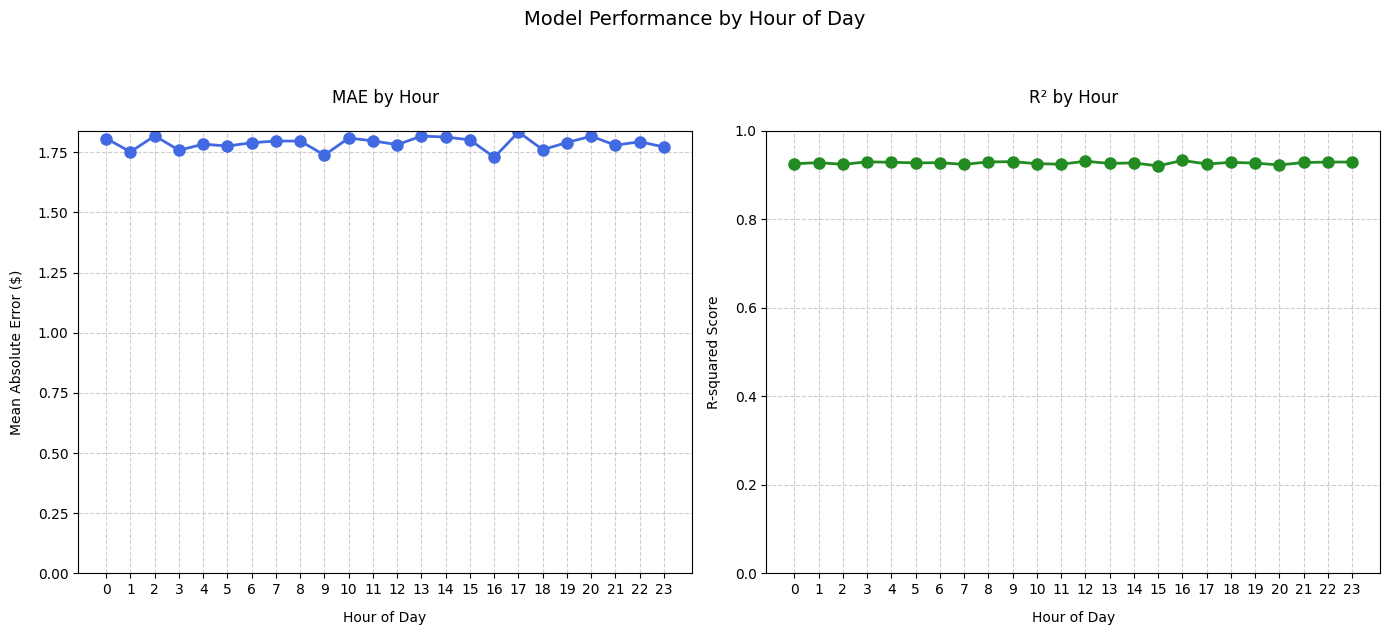

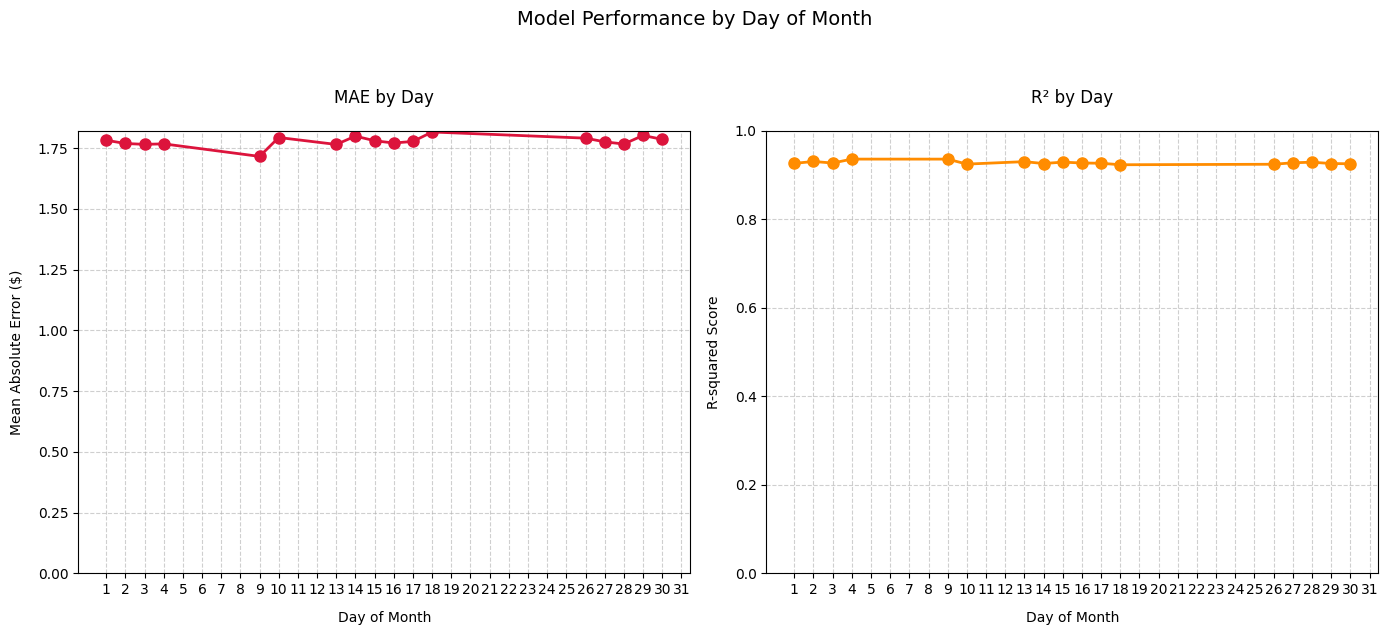

In [78]:


features = ['cab_type', 'name', 'distance', 'surge_multiplier', 'price', 'datetime']
df_time = df[features].copy()
df_time['hour'] = df_time['datetime'].dt.hour
df_time['day'] = df_time['datetime'].dt.day


for col in ['cab_type', 'name']:
    target_means = df_time.groupby(col)['price'].mean()
    df_time[f'{col}_te'] = df_time[col].map(target_means)


X = df_time[['distance', 'surge_multiplier', 'cab_type_te', 'name_te']]
y = df_time['price']

def evaluate_by_time_segment(time_col, segment_name):
    results = []
    unique_values = sorted(df_time[time_col].unique())

    for value in unique_values:
        mask = df_time[time_col] == value
        X_segment = X[mask]
        y_segment = y[mask]

        if len(X_segment) > 100:
            X_train, X_test, y_train, y_test = train_test_split(
                X_segment, y_segment, test_size=0.2, random_state=42
            )

            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)

            model = LinearRegression()
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)

            mae = mean_absolute_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)

            results.append({
                segment_name: value,
                'mae': mae,
                'r2': r2,
                'sample_size': len(X_segment)
            })

    return pd.DataFrame(results)


hourly_results = evaluate_by_time_segment('hour', 'hour')


daily_results = evaluate_by_time_segment('day', 'day')

plt.figure(figsize=(14, 6))
plt.suptitle('Model Performance by Hour of Day', y=1.05, fontsize=14)

# MAE by Hour
plt.subplot(1, 2, 1)
plt.plot(hourly_results['hour'], hourly_results['mae'],
         marker='o', color='royalblue', linewidth=2, markersize=8)
plt.title('MAE by Hour', pad=20)
plt.xlabel('Hour of Day', labelpad=10)
plt.ylabel('Mean Absolute Error ($)', labelpad=10)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(bottom=0)

# R² by Hour
plt.subplot(1, 2, 2)
plt.plot(hourly_results['hour'], hourly_results['r2'],
         marker='o', color='forestgreen', linewidth=2, markersize=8)
plt.title('R² by Hour', pad=20)
plt.xlabel('Hour of Day', labelpad=10)
plt.ylabel('R-squared Score', labelpad=10)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()


plt.figure(figsize=(14, 6))
plt.suptitle('Model Performance by Day of Month', y=1.05, fontsize=14)

# MAE by Day
plt.subplot(1, 2, 1)
plt.plot(daily_results['day'], daily_results['mae'],
         marker='o', color='crimson', linewidth=2, markersize=8)
plt.title('MAE by Day', pad=20)
plt.xlabel('Day of Month', labelpad=10)
plt.ylabel('Mean Absolute Error ($)', labelpad=10)
plt.xticks(range(1, 32))
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(bottom=0)

# R^2 by Day
plt.subplot(1, 2, 2)
plt.plot(daily_results['day'], daily_results['r2'],
         marker='o', color='darkorange', linewidth=2, markersize=8)
plt.title('R² by Day', pad=20)
plt.xlabel('Day of Month', labelpad=10)
plt.ylabel('R-squared Score', labelpad=10)
plt.xticks(range(1, 32))
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

